In [ ]:
!pip install kagglehub tensorflow matplotlib seaborn scikit-learn

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "andrewmvd/face-mask-detection"
)

print("Dataset Path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'face-mask-detection' dataset.
Dataset Path: /kaggle/input/face-mask-detection
['annotations', 'images']


In [ ]:
data_dir = path

print(os.listdir(data_dir))

['annotations', 'images']


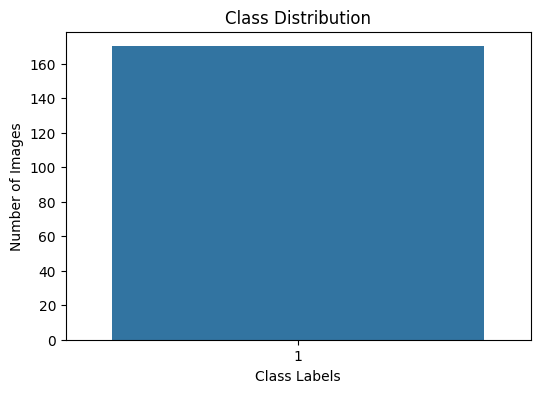

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Class counts
class_counts = val_data.classes

plt.figure(figsize=(6,4))

sns.countplot(x=class_counts)

plt.title("Class Distribution")
plt.xlabel("Class Labels")
plt.ylabel("Number of Images")

plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7,1.3],
    shear_range=0.2,
    validation_split=0.2
)

In [ ]:
train_data = train_datagen.flow_from_directory(
    data_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 683 images belonging to 2 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(256,(3,3),activation='relu'))   # NEW LAYER
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))  # increased neurons
model.add(Dropout(0.5))

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print(classification_report(true_labels, preds))

In [ ]:
history = model.fit(
    train_data,
    epochs=30,
    validation_data=val_data
)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 29s 944ms/step - accuracy: 0.9795 - loss: 0.0545 - val_accuracy: 0.0000e+00 - val_loss: 0.8324
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 763ms/step - accuracy: 1.0000 - loss: 4.4364e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.9884
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 662ms/step - accuracy: 1.0000 - loss: 4.7896e-04 - val_accuracy: 0.0000e+00 - val_loss: 1.0695
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 782ms/step - accuracy: 1.0000 - loss: 4.7900e-04 - val_accuracy: 0.0000e+00 - val_loss: 1.0771
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 766ms/step - accuracy: 1.0000 - loss: 1.6484e-04 - val_accuracy: 0.0000e+00 - val_loss: 1.0234
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 661ms/step - accuracy: 1.0000 - loss: 2.0948e-04 - val_accuracy: 0.0000e+00 - val_loss: 0.9200
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 695ms/step - accuracy: 1.0000 - loss: 1.7801e-04 - val_accuracy: 0.2765 - val_loss: 0.7504
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 667ms/s

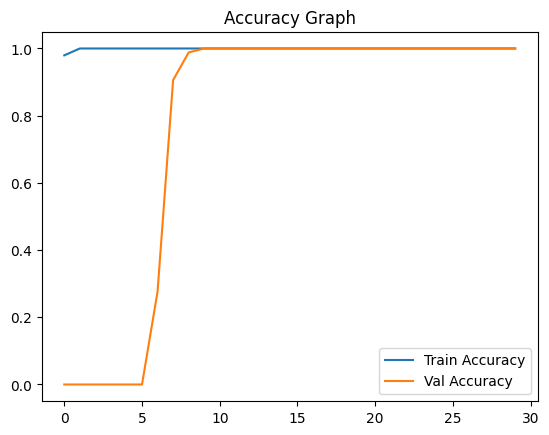

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')

plt.legend()
plt.title("Accuracy Graph")
plt.show()

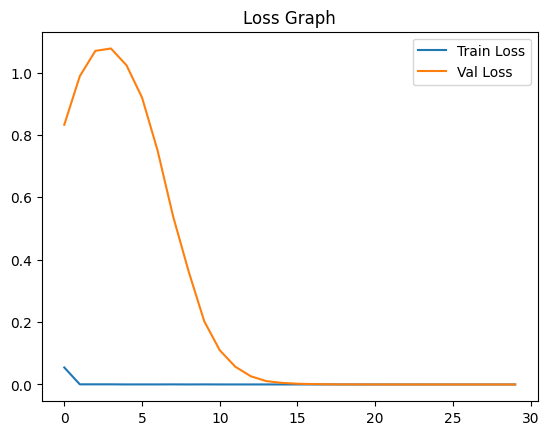

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title("Loss Graph")
plt.show()

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,782,913 (10.62 MB)

 Trainable params: 2,781,953 (10.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
preds = model.predict(val_data)
preds = (preds > 0.5).astype(int).flatten()

true_labels = val_data.classes[:len(preds)]

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 445ms/step


In [ ]:
print(classification_report(true_labels, preds))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       170

    accuracy                           1.00       170
   macro avg       1.00      1.00      1.00       170
weighted avg       1.00      1.00      1.00       170



6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 588ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


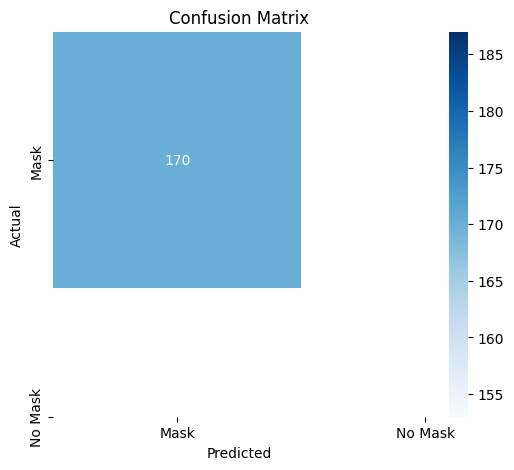

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
preds = model.predict(val_data)
preds = (preds > 0.5).astype(int).flatten()

# True labels
true_labels = val_data.classes[:len(preds)]

# Confusion Matrix
cm = confusion_matrix(true_labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Mask', 'No Mask'],
    yticklabels=['Mask', 'No Mask']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step


/tmp/ipykernel_8304/2665898216.py:28: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


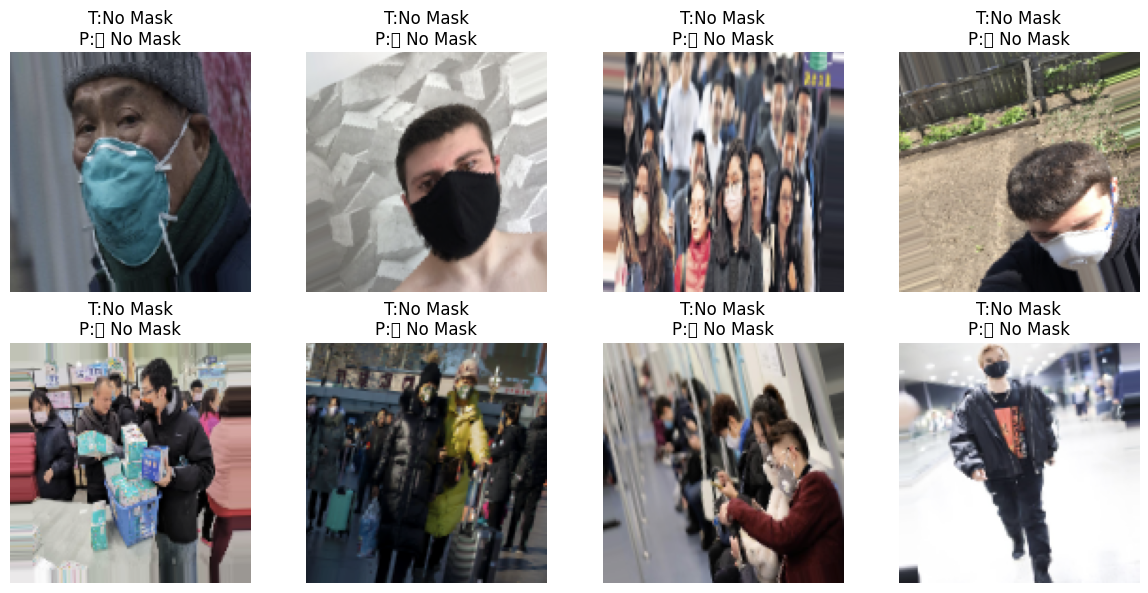

In [ ]:
images, labels = next(val_data)

preds = model.predict(images)
preds = (preds > 0.5).astype(int).flatten()

plt.figure(figsize=(12,6))

for i in range(8):

    plt.subplot(2,4,i+1)
    plt.imshow(images[i])

    pred_label = (
        "❌ No Mask"
        if preds[i] == 1
        else "✅ Mask"
    )

    true_label = (
        "No Mask"
        if labels[i] == 1
        else "Mask"
    )

    plt.title(f"T:{true_label}\nP:{pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()